# **[추가] 종합실습_Agentic RAG**

## **1.환경준비**

### (1) 구글 드라이브

#### 1) 구글 드라이브 폴더 생성
* 새 폴더(LangGraph)를 생성하고
* 제공 받은 파일을 업로드

#### 2) 구글 드라이브 연결

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### (2) 라이브러리

#### 1) 필요한 라이브러리 설치

In [2]:
!pip install langchain-openai langchain langgraph typing typing_extensions langchain_core langchain-community wikipedia chromadb google-search-results -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 5.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.4/155.4 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.8/449.8 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.9/19.9 MB 93.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

#### 2) 라이브러리 로딩

In [3]:
import pandas as pd
import numpy as np
import os
import openai

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

from typing import Annotated, Literal, Sequence, TypedDict
from langchain import hub
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, AIMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI
from langchain.embeddings import OpenAIEmbeddings
from langchain.vectorstores import Chroma
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field
from langgraph.prebuilt import tools_condition

### (3) OpenAI API Key 확인

In [4]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/LangGraph/'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

⚠️ 아래 코드셀은, 실행해서 key가 제대로 보이는지 확인하고 삭제하세요.

In [5]:
print(os.environ['OPENAI_API_KEY'][:30])

sk-proj-9_V5Db5A_3EzpkFeDNhezt


## 2.Agentic RAG 구현해보기

* empedding 모델 : text-embedding-3-small
* gpt : gpt-4.1-mini

### (1) VectorDB 준비(retriever)

In [6]:
from langchain.document_loaders import CSVLoader

# CSV 파일 로드
csv_path = "aivleschool_qa_utf8.csv"
csv_loader = CSVLoader(file_path= path + csv_path)
documents_csv = csv_loader.load()

# 벡터 DB 정의
embedding = OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore = Chroma.from_documents(documents_csv, embedding,
                                    persist_directory="chroma_db")

retriever = vectorstore.as_retriever()

/tmp/ipython-input-2052414895.py:9: LangChainDeprecationWarning: The class `OpenAIEmbeddings` was deprecated in LangChain 0.0.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import OpenAIEmbeddings``.
  embedding = OpenAIEmbeddings(model="text-embedding-3-small")


In [7]:
from langchain.tools.retriever import create_retriever_tool

retriever_tool = create_retriever_tool(
    retriever,
    "search_aivle_school_DB",  # 함수 이름은 영문, 띄어쓰기 없어야함.
    '''aivle school(에이블스쿨)에 대한 FAQ DB에서 적절한 답변을 찾으세요.''',
)

tools = [retriever_tool]

### (2) Agentic RAG 노드 및 엣지 정의

#### 1) Agent의 상태 정의

Agent는 메시지를 상태로 저장하고, 새로운 메시지가 추가될 때마다 업데이트합니다.


In [8]:
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

- AgentState: 시스템이 다루는 상태 정보를 정의 (메시지 리스트)
- add_messages: 기존 메시지 목록을 유지하면서 새로운 메시지를 추가 (덮어쓰기 X)


#### 3) Agent가 검색할지 여부 결정 (agent)

Agent는 검색이 필요한지 판단하고, 검색 도구를 실행할지 결정합니다.

In [9]:
def agent(state):
    """
    Agent 모델을 실행하여 검색할지 결정합니다.
    """
    print("---Agent 실행---")

    messages = state["messages"]
    model = ChatOpenAI(temperature=0, streaming=True, model="gpt-4.1-mini")

    # 검색 도구를 Agent와 연결
    model = model.bind_tools(tools)

    # Agent 실행
    response = model.invoke(messages)

    # 새로운 응답 메시지를 상태에 추가하여 반환
    return {"messages": [response]}


#### 2) 검색된 문서의 적절성 평가 (grade_documents)

검색된 문서가 질문과 관련이 있는지 판단하는 노드입니다.

In [10]:
def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    검색된 문서가 사용자 질문과 관련이 있는지 판단합니다.
    - 관련성이 높으면 'generate' (답변 생성)으로 이동
    - 관련성이 낮으면 'rewrite' (검색어 개선)으로 이동
    """

    print("---검색된 문서의 적절성 평가 수행---")

    # 문서 적절성 평가 모델 정의
    class grade(BaseModel):
        """검색된 문서의 적절성을 평가하는 이진 점수 (yes 또는 no)"""
        binary_score: str = Field(description="검색된 문서의 적절성 점수 (예: 'yes' 또는 'no')")

    # OpenAI gpt-4.1-mini 모델 설정
    model = ChatOpenAI(temperature=0, model="gpt-4.1-mini", streaming=True)
    llm_with_tool = model.with_structured_output(grade)

    # 프롬프트 템플릿 정의
    prompt = PromptTemplate(
        template="""당신은 검색된 문서가 사용자 질문과 관련이 있는지 평가하는 역할을 수행합니다.
        다음은 검색된 문서입니다: \n\n {context} \n\n
        다음은 사용자 질문입니다: {question} \n
        문서가 질문과 관련된 키워드나 의미를 포함하고 있다면 'yes', 아니라면 'no'를 출력하세요.""",
        input_variables=["context", "question"],
    )

    # 체인 실행
    chain = prompt | llm_with_tool
    messages = state["messages"]
    last_message = messages[-1]  # 최근 메시지 (검색된 문서)
    question = messages[0].content  # 원본 질문

    # 검색된 문서와 질문을 LLM에 입력하여 적절성 평가 수행
    scored_result = chain.invoke({"question": question, "context": last_message.content})
    score = scored_result.binary_score

    # 문서가 적절하면 답변 생성(generate), 그렇지 않으면 검색어 개선(rewrite)
    if score == "yes":
        print("---결정: 문서가 관련 있음 (답변 생성으로 이동)---")
        return "generate"
    else:
        print("---결정: 문서가 관련 없음 (검색어 개선으로 이동)---")
        return "rewrite"


#### 4) 검색어 개선 (rewrite)

검색된 문서가 적절하지 않다면, 검색어를 개선하여 다시 검색합니다.

In [11]:
def rewrite(state):
    """
    검색어를 보다 적절하게 변경하여 검색 성능을 향상시킵니다.
    """
    print("---검색어 개선 수행---")

    messages = state["messages"]
    question = messages[0].content

    # 검색어 개선을 위한 메시지 생성
    msg = [
        HumanMessage(
            content=f"""
    입력된 질문을 보고 의미적으로 더 적절한 표현을 찾아보세요.
    다음은 원본 질문입니다:
    {question}
    더 나은 검색어로 변환하세요:
            """
        )
    ]

    # GPT-4를 사용하여 검색어 개선 수행
    model = ChatOpenAI(temperature=0, model="gpt-4.1-mini", streaming=True)
    response = model.invoke(msg)

    return {"messages": [response]}


#### 5) 답변 생성 (generate)

In [12]:
from langchain_core.output_parsers import StrOutputParser
from langchain.prompts import ChatPromptTemplate
from langchain_core.messages import AIMessage

def generate(state):
    """
    검색된 문서를 기반으로 답변 생성을 시도합니다.
    """
    print("---답변 생성 시작---")

    messages = state["messages"]
    question = messages[0].content             # 사용자의 질문
    last_message = messages[-1]                # ToolMessage (검색 결과)
    docs = last_message.content                # 검색된 문서 내용 (text)


    # 프롬프트 정의
    prompt = ChatPromptTemplate.from_template(
        '''당신은 에이블스쿨에 대한 질문에 답변을 수행하는 어시스턴트입니다..
        다음 Context 를 기반으로 답변하세요.
        만약 질문에 적절한 Context가 아니라면, 정확한 정보가 아님을 전제로 일반적인 답변을 하세요.
        답변시 최대 3 문장 이내로 간결하게 답하세요.

        Question: {question}
        Context: {context}
        Answer:'''
    )

    llm = ChatOpenAI(model_name="gpt-4.1-mini", temperature=0, streaming=True)

    # 체인 구성 (LCEL 방식)
    rag_chain = prompt | llm # | StrOutputParser()

    response = rag_chain.invoke({"question": question, "context": docs})

    return {"messages": [AIMessage(content=response.content)]}

### (3) 그래프 구축 및 실행

In [13]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode

# 새로운 상태 그래프 정의
workflow = StateGraph(AgentState)

# 노드 추가
workflow.add_node("agent", agent)
retrieve = ToolNode([retriever_tool])
workflow.add_node("retrieve", retrieve)
workflow.add_node("rewrite", rewrite)
workflow.add_node("generate", generate)

# 엣지 추가: Agent → 검색 또는 종료
workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", tools_condition, {"tools": "retrieve", END: END})
workflow.add_conditional_edges("retrieve", grade_documents)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# 그래프 컴파일
graph = workflow.compile()


* 시각화

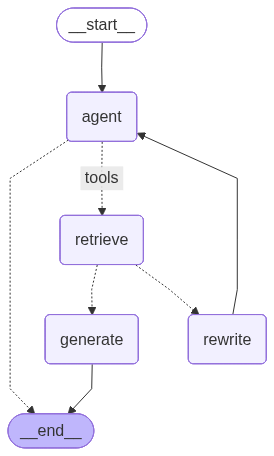

In [14]:
from IPython.display import Image, display

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

### (4) 실행

In [15]:
import pprint

inputs = {
    "messages": [
        ("user", "에이블스쿨 지원자격은?"),
    ]
}
for output in graph.stream(inputs):
    for key, value in output.items():
        pprint.pprint(f"Output from node '{key}':")
        pprint.pprint("---")
        pprint.pprint(value, indent=2, width=80, depth=None)
    pprint.pprint("\n---\n")

---Agent 실행---
"Output from node 'agent':"
'---'
{ 'messages': [ AIMessage(content='', additional_kwargs={'tool_calls': [{'index': 0, 'id': 'call_psF5meRpodmyglLPfKeeCrc8', 'function': {'arguments': '{"query":"에이블스쿨 지원자격"}', 'name': 'search_aivle_school_DB'}, 'type': 'function'}]}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_c064fdde7c', 'service_tier': 'default'}, id='run--5bba228d-3d44-439c-9b92-56f64787b414-0', tool_calls=[{'name': 'search_aivle_school_DB', 'args': {'query': '에이블스쿨 지원자격'}, 'id': 'call_psF5meRpodmyglLPfKeeCrc8', 'type': 'tool_call'}], usage_metadata={'input_tokens': 85, 'output_tokens': 25, 'total_tokens': 110, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}
'\n---\n'
---검색된 문서의 적절성 평가 수행---
---결정: 문서가 관련 있음 (답변 생성으로 이동)---
"Output from node 'retrieve':"
'---'
{ 'messages': [ ToolMessage(content='\ufeff구분: 모집/선발\nQA: 직장인도 지원할 수 있나요?\

In [16]:
result = graph.invoke(inputs)

---Agent 실행---
---검색된 문서의 적절성 평가 수행---
---결정: 문서가 관련 있음 (답변 생성으로 이동)---
---답변 생성 시작---


In [17]:
result['messages']

[HumanMessage(content='에이블스쿨 지원자격은?', additional_kwargs={}, response_metadata={}, id='6cc0b5b9-1850-4d0d-9e9d-fc0a77bb3aa2'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'index': 0, 'id': 'call_vwswBV5oPIfKcWp23AsAXs5Y', 'function': {'arguments': '{"query":"에이블스쿨 지원자격"}', 'name': 'search_aivle_school_DB'}, 'type': 'function'}]}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_c064fdde7c', 'service_tier': 'default'}, id='run--5b298019-1da3-4dd0-9e03-78a07c881233-0', tool_calls=[{'name': 'search_aivle_school_DB', 'args': {'query': '에이블스쿨 지원자격'}, 'id': 'call_vwswBV5oPIfKcWp23AsAXs5Y', 'type': 'tool_call'}], usage_metadata={'input_tokens': 85, 'output_tokens': 25, 'total_tokens': 110, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}),
 ToolMessage(content='\ufeff구분: 모집/선발\nQA: 직장인도 지원할 수 있나요?\nKT 에이블스쿨은 미취업자를 대상으로 하며, 교육 시작일 기준 재직자는 지원이 불가능합니다. 향후 취업

In [18]:
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

에이블스쿨 지원자격은?
================================== Ai Message ==================================
Tool Calls:
  search_aivle_school_DB (call_vwswBV5oPIfKcWp23AsAXs5Y)
 Call ID: call_vwswBV5oPIfKcWp23AsAXs5Y
  Args:
    query: 에이블스쿨 지원자격
================================= Tool Message =================================
Name: search_aivle_school_DB

﻿구분: 모집/선발
QA: 직장인도 지원할 수 있나요?
KT 에이블스쿨은 미취업자를 대상으로 하며, 교육 시작일 기준 재직자는 지원이 불가능합니다. 향후 취업여부를 확인할 예정입니다.

﻿구분: 모집/선발
QA: 최종 학력 또는 전공과 관계없이 지원할 수 있나요?
KT 에이블스쿨은 정규 4년제 대학 졸업자 및 졸업예정자를 대상으로 하는 교육입니다. 전공에 관계 없이 명시된 지원 자격에 부합한다면 모두 지원 가능합니다. 다만, AI개발자 Track은 기본적인 코딩역량이 필요합니다.

﻿구분: 모집/선발
QA: 다른 K-DT 과정을 들었는데 지원할 수 있나요?
K-DT 교육과정은 최초 1회에 한해서만 무료 수강이 가능하며, KT 에이블스쿨은 본인 부담금이 발생하는 경우 지원이 어렵습니다. K-DT 과정마다 차이가 있을 수 있으니 개인별 정확한 수강 가능 여부는 관할 고용센터에 확인 부탁드립니다. 관할 고용센터 정보는 고용노동부 대표번호 1350 또는 거주지 근처 지도검색, HRD-Net에서 확인 가능합니다.

﻿구분: 모집/선발
QA: 아르바이트를 하고 있는데 지원할 수 있나요?
고용보험에 가입이 되어 있는 경우 1